This notebook fits the deflector light profile of WGD 2038-4008 from a large cutout using isophote-based elliptical model.

### imports

In [1]:
import numpy as np
import os
import h5py
import joblib

import lenstronomy.Util.util as util
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Plots import chain_plot
from lenstronomy.Sampling.parameters import Param
#from lenstronomy.Analysis.lens_analysis import LensAnalysis
from lenstronomy.Util import mask_util
from lenstronomy.Data.coord_transforms import Coordinates
from lenstronomy.Util.util import array2image


from lenstronomy.Util import param_util

cwd = os.getcwd()
base_path, _ = os.path.split(cwd)
print('Base directory path:', base_path)

Base directory path: /Users/ajshajib/Research/time_delay_cosmography/J2038/WGD2038-4008/lenstronomy_modeling


### plot settings

In [2]:
import matplotlib as mpl
import paperfig as pf

msh_cmap = pf.msh_cmap
msh_cmap2 = pf.msh_cmap2

pf.set_fontscale(2.)

### functions

In [3]:
from photutils import detect_threshold
from astropy.convolution import Gaussian2DKernel
from astropy.stats import gaussian_fwhm_to_sigma
from photutils import detect_sources
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils import deblend_sources
import numpy as np
import astropy.units as u
from photutils import source_properties, EllipticalAperture
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize


def get_mask(large_image, bkg_rms):
    """
    Create a mask covering the nearby stars/galaxies.
    """
    #threshold = detect_threshold(data, nsigma=2.)

    threshold = (3.0 * bkg_rms)  

    sigma = 6.0 * gaussian_fwhm_to_sigma  # FWHM = 3.
    kernel = Gaussian2DKernel(sigma, x_size=3, y_size=3)
    kernel.normalize()
    segm = detect_sources(large_image, threshold, npixels=5, filter_kernel=kernel)


    norm = ImageNormalize(stretch=SqrtStretch())
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12.5))
    ax1.imshow(large_image, origin='lower', cmap='Greys_r', norm=norm)
    ax1.set_title('Data')
    cmap = segm.make_cmap(random_state=12345)
    ax2.imshow(segm, origin='lower', cmap=cmap)
    ax2.set_title('Segmentation Image')


    segm_deblend = deblend_sources(large_image, segm, npixels=9,
                                   filter_kernel=kernel, nlevels=32,
                                   contrast=0.01)


    cat = source_properties(large_image, segm_deblend)
    r = 3.  # approximate isophotal extent
    apertures = []
    for obj in cat:
        position = np.transpose((obj.xcentroid.value, obj.ycentroid.value))
        a = obj.semimajor_axis_sigma.value * r
        b = obj.semiminor_axis_sigma.value * r
        theta = obj.orientation.to(u.rad).value
        apertures.append(EllipticalAperture(position, a, b, theta=theta))


    norm = ImageNormalize(stretch=SqrtStretch())
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12.5))
    ax1.imshow(large_image, origin='lower', cmap='Greys_r', norm=norm)
    ax1.set_title('Data')
    cmap = segm_deblend.make_cmap(random_state=12345)
    ax2.imshow(segm_deblend, origin='lower', cmap=cmap)
    ax2.set_title('Segmentation Image')
    for aperture in apertures:
        aperture.plot(axes=ax1, color='white', lw=1.5)
        aperture.plot(axes=ax2, color='white', lw=1.5)

    a = np.array(segm_deblend)

    s = set(a.flatten())
    area = []

    for num in s:
        if num == 0:
            continue
        counter = np.zeros_like(a)
        counter[a == num] = 1
        area.append(np.sum(counter))

    central_id = list(s)[np.argmax(area)]+1

    a[a == central_id] = 0

    plt.matshow(a, origin='lower')
    plt.title('initial segmented mask')
    plt.show()

    kernel = np.ones((11, 11),np.uint8)

    dilation = cv2.dilate(a.astype(np.uint8), kernel, iterations=1)

    plt.matshow(dilation, origin='lower')
    plt.title('dilated mask')
    plt.show()
    
    large_mask = np.zeros_like(dilation)
    large_mask[dilation == 0] = 1

    plt.matshow(np.log10(large_image*large_mask), origin='lower')
    plt.show()
    
    return large_mask

# Fit profiles

In [4]:
import warnings
warnings.filterwarnings('ignore')
import cv2
import copy
import h5py

import paperfig as pf
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import coloripy as cp

import lenstronomy.Util.class_creator as class_creator
from lenstronomy.ImSim.MultiBand.single_band_multi_model import SingleBandMultiModel

### load a model run to subtract the lensed arcs and QSO images from the deflector 

In [5]:
job_name_out = '2038_run143_0_1_2_0_0_shortened'

input_temp = os.path.join(base_path, 'temp', job_name_out +'.txt')
output_temp = os.path.join(base_path, 'temp', job_name_out +'_out.txt')

f = open(output_temp, 'rb')
[input_, output_] = joblib.load(f)
f.close()

fitting_kwargs_list, kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params, init_samples = input_

kwargs_result, multi_band_list_out, fit_output, _ = output_

band_index = 2

kwargs_data, kwargs_psf, _ = multi_band_list_out[band_index]

samples_mcmc = np.array(fit_output[-1][1])
medians = np.median(samples_mcmc, axis=0)

# walker_ratio = 8

# mcmc_repeat = 1

# samples_mcmc = np.array(fit_output[-1][1])

# print('Shape of MCMC chain:', samples_mcmc.shape)

# n_params = samples_mcmc.shape[1]

# n_walkers = 8 * n_params
# n_step = int(samples_mcmc.shape[0] / n_walkers)

# print('n_step: {}, n_walkers: {}, n_params: {}'.format(n_step, n_walkers, n_params))

# chain = np.empty((n_walkers, n_step, n_params))


# for i in np.arange(n_params):
#     samples = samples_mcmc[:, i].T
#     chain[:,:,i] = samples.reshape((n_step, n_walkers)).T


# mean_pos = np.zeros((n_params, n_step))
# median_pos = np.zeros((n_params, n_step))
# std_pos = np.zeros((n_params, n_step))
# q16_pos = np.zeros((n_params, n_step))
# q84_pos = np.zeros((n_params, n_step))

# for i in np.arange(n_params):
#     for j in np.arange(n_step):
#         mean_pos[i][j] = np.mean(chain[:, j, i])
#         median_pos[i][j] = np.median(chain[:, j, i])
#         std_pos[i][j] = np.std(chain[:, j, i])
#         q16_pos[i][j] = np.percentile(chain[:, j, i], 16.)
#         q84_pos[i][j] = np.percentile(chain[:, j, i], 84.)
        
# burnin = -1
# last = n_step

# medians = []

# for i in range(n_params):
#     medians.append(np.median(median_pos[i][burnin:last]))

param_class = Param(kwargs_model,
                kwargs_params['lens_model'][2], 
                kwargs_params['source_model'][2],
                kwargs_params['lens_light_model'][2],
                kwargs_params['point_source_model'][2],
                kwargs_lens_init=kwargs_params['lens_model'][0], 
                **kwargs_constraints
               )

kwargs_median = param_class.args2kwargs(medians)

**Here, we subtract the lensed arcs and the quasar images from the large cutout image.**

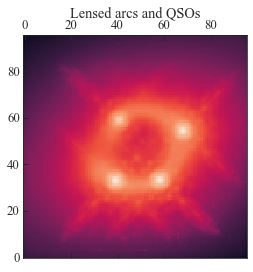

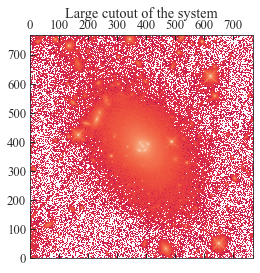

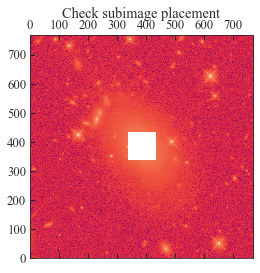

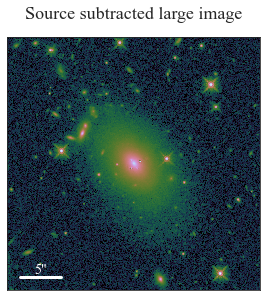

In [6]:
from rgb_functions import *

mask_list = kwargs_likelihood['image_likelihood_mask_list']
band_bool = [True] * 3
band_bool[band_index] = True

pf.set_fontscale(1.6)
fontsize = pf.mnras_figcaption_fontsize*1.6



image_model = class_creator.create_im_sim(multi_band_list_out, kwargs_data_joint['multi_band_type'], 
                                          kwargs_model,
                                          bands_compute=band_bool,
                                          likelihood_mask_list=mask_list)

model, error_map, cov_param, param = image_model.image_linear_solve(inv_bool=True, **kwargs_median)
    

band_model = SingleBandMultiModel(multi_band_list_out, kwargs_model, likelihood_mask_list=mask_list,
                                  band_index=band_index)

kwargs_lens_partial, kwargs_source_partial, kwargs_lens_light_partial, kwargs_ps_partial, _kwargs_extinction_partial = band_model.select_kwargs(**kwargs_median)
_kwargs_lens_partial, _kwargs_source_partial, _kwargs_lens_light_partial, _kwargs_ps_partial = band_model.update_linear_kwargs(param[band_index], kwargs_lens_partial, kwargs_source_partial, kwargs_lens_light_partial, kwargs_ps_partial)


data = kwargs_data['image_data']

lensed_arcs = band_model.image(_kwargs_lens_partial, _kwargs_source_partial, _kwargs_lens_light_partial,
                                          _kwargs_ps_partial, unconvolved=False, source_add=True,
                                          lens_light_add=False, point_source_add=True)

lensed_source = lensed_arcs #data - lensed_arcs

plt.matshow(np.log10(lensed_arcs), origin='lower')
plt.title('Lensed arcs and QSOs')
plt.show()

filt = 'F160W'
data_filename = '../data/data_f160w_large_cutout.hdf5'
local_data_filename = data_filename #os.path.join(base_path, 'data', data_filename)
f = h5py.File(local_data_filename, "r")

large_image_backup = f['image_data'][()]
bkg_rms = f['background_rms'][()]
wht_map = f['exposure_map'][()]
ra_at_xy_0 = f['ra_at_xy_0'][()]
dec_at_xy_0 = f['dec_at_xy_0'][()]
Matrix_inv = f['transform_pix2angle'][()]
f.close()

kwargs_data_large = {'image_data': large_image_backup, 
               'background_rms': bkg_rms,
               'noise_map': None,
               'exposure_time': wht_map,
               'ra_at_xy_0': ra_at_xy_0,
               'dec_at_xy_0': dec_at_xy_0, 
               'transform_pix2angle': Matrix_inv
               }

plt.matshow(np.log10(large_image_backup), origin='lower')
plt.title('Large cutout of the system')
plt.show()

result = cv2.matchTemplate(data.astype(np.float32), large_image_backup.astype(np.float32), cv2.TM_CCOEFF_NORMED)
match = np.unravel_index(result.argmax(),result.shape)

large_image = copy.deepcopy(large_image_backup)
large_image[match[0]:match[0]+len(lensed_source), match[1]:match[1]+len(lensed_source)] -= data

plt.matshow(np.log10(np.abs(large_image)), origin='lower')
plt.title('Check subimage placement')
plt.show()

large_image = copy.deepcopy(large_image_backup)
large_image[match[0]:match[0]+len(lensed_source), match[1]:match[1]+len(lensed_source)] -= lensed_source*mask_list[band_index]

fig = plt.figure(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))
ax = fig.add_subplot(111)
ax.matshow(np.log10(np.abs(large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title('Source subtracted large image', fontdict={'fontsize': pf.mnras_text_fontsize*2})

add_scale_bar(ax, length=5, fontsize=14, scale_text=None);
    
ax.set_xticks([])
ax.set_yticks([])
# plt.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/source_subtracted_large_cutout.pdf', 
#             bbox_inches='tight')
plt.show()

#large_mask = get_mask(large_image, bkg_rms)

#import numpy.ma as ma

#masked_data = ma.masked_array(large_image, 1-large_mas#

## Fit isophotes using `photutils`

In [7]:
from photutils.isophote import Ellipse, EllipseGeometry
from photutils.isophote import build_ellipse_model

**First fit the isophotes in the inner region.**

In [8]:
g = EllipseGeometry(242.+96*1.5, 240+96*1.5, 60., 0.3, 120./180.*np.pi)
g.find_center(large_image)

ellipse = Ellipse(large_image, geometry=g)
isolist = ellipse.fit_image(integrmode='median', sclip=3.0, nclip=3, fflag=0.7, maxsma=90.)

INFO: Found center at x0 = 386.0, y0 = 384.0 [photutils.isophote.geometry]


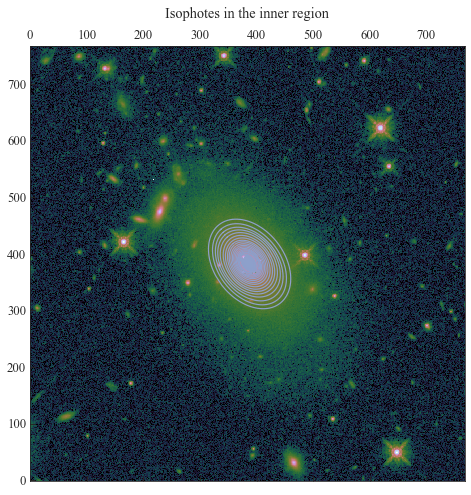

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.matshow(np.log10(np.abs(large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title("Isophotes in the inner region")
#ax.set_xlim([300, 900])
#ax.set_ylim([700, 1200])

# go to the outermost successfully fitted ellipse at sma=235
isos = []
for sma in isolist.to_table()['sma']:
    iso = isolist.get_closest(sma)
    isos.append(iso)
    x, y, = iso.sampled_coordinates()
    plt.plot(x, y, color=pf.cb2_blue)



In [10]:
isolist.to_table()

sma,intens,intens_err,ellipticity,ellipticity_err,pa,pa_err,grad,grad_err,grad_rerr,x0,x0_err,y0,y0_err,ndata,flag,niter,stop_code
,,,,,deg,deg,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,float64,float64,float64,int64,int64,int64,int64
0.0,28.167439521693524,0.0,0.0,0.0,0.0,0.0,0.0,None,None,385.6100920127983,0.0,383.99076551092804,0.0,1,0,0,0
0.5111130767700377,28.02410033614951,0.005742454695630859,0.8674744290769626,0.005313802145902547,178.6899877926777,0.3308838874590289,-0.26910040526706447,0.1684770106102008,0.6260749048036491,385.6100920127983,0.010261159102465455,383.99076551092804,0.0014651432160076527,13,0,50,2
0.5622243844470415,27.937654762187403,0.011885237893183343,0.8218609828070741,0.008008956664302564,178.6899877926777,0.5061389046690082,-0.5060957263113203,0.28496547718554144,0.563066357549614,385.55507448605243,0.01266017600224809,383.9853585612691,0.0024158901062138844,13,0,26,0
0.6184468228917457,27.66400704375316,0.031561163227715426,0.6462873764774695,0.012268771432829144,175.9224575830541,0.8579967023826912,-1.5770985398137634,0.9806438196339382,0.6218025030634678,385.52647072713194,0.01072128926340918,383.9735791426033,0.004103336673625171,13,0,10,0
0.6802915051809203,27.320513533298616,0.041937480808692744,0.4519374302749299,0.014866979404189443,171.84347446505225,1.300138204324024,-2.4420796292539166,1.0937779722789869,0.44788792272639716,385.5232669406608,0.009182300339171293,383.9478360357695,0.005492117545712604,13,0,11,0
0.7483206556990124,26.910944510763116,0.05364079850533813,0.26103257768799687,0.018007470695573548,162.770617179071,2.4273211780761184,-3.1688262086158767,1.1844717705874885,0.37378880778219087,385.5345938904041,0.008979478698644407,383.92975194250914,0.007370902553003442,13,0,10,0
0.8231527212689137,26.55243590540785,0.049960947566764786,0.17355209296820653,0.015659069259796012,148.48479530985125,3.0228637312088473,-3.452791251944827,1.0278522649264616,0.297687346244147,385.5142319139653,0.007565580848025154,383.9239230956662,0.007137342860294591,13,0,10,0
0.9054679933958051,26.323455863916106,0.052664139258818736,0.1778037122101518,0.014080463094097266,136.26240498679235,2.658970993317178,-3.6599572917737886,0.8963003350203241,0.2448936595612389,385.51225347936344,0.007317333338503665,383.91347042231354,0.007274442016006169,13,0,10,0


Check the intensity along the isophotes. For a good fit the same colored dots should follow horizontal lines.

Text(0, 0.5, 'Intensity')

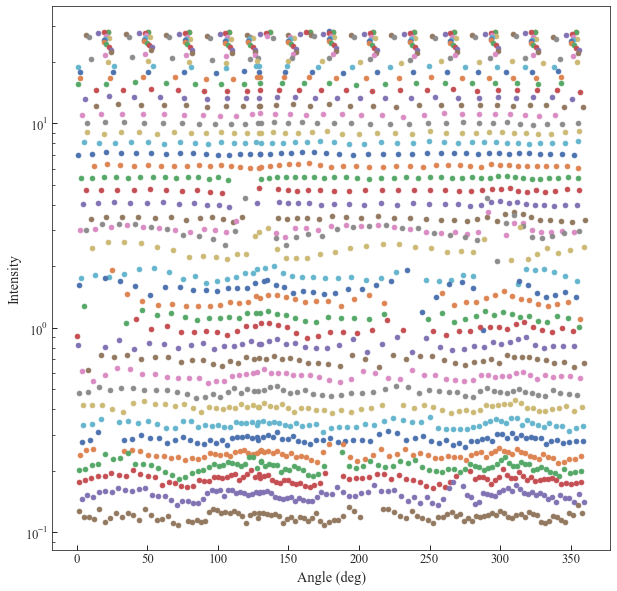

In [11]:
plt.figure(figsize=(10, 10))

for iso in isos:
    angles = ((iso.sample.values[0] + iso.sample.geometry.pa) / np.pi*180.) % 360.
    plt.scatter(angles, iso.sample.values[2])
    
plt.yscale('log')
plt.xlabel("Angle (deg)")
plt.ylabel("Intensity")

Plot the isophote-based model for the inner region.

Text(0.5, 1.05, 'Inner region model')

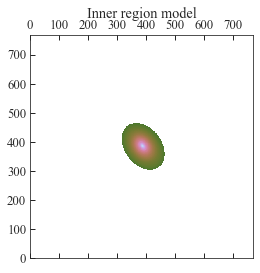

In [12]:
model_image = build_ellipse_model(large_image.shape, isolist)
#residual = data - model_image

plt.matshow(np.log10(model_image), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
plt.title('Inner region model')

In [13]:
#plt.matshow(np.log10(model_image), origin='lower')

**Fit the outer region. The step sizes between subsequent isophotes are different in the outer region.**

In [14]:
g = EllipseGeometry(242.+96*1.5, 240+96*1.5, 60., 0.3, 120./180.*np.pi)
g.find_center(large_image)

ellipse = Ellipse(large_image, geometry=g)
isolist_outer = ellipse.fit_image(integrmode='median', step=0.1, minsma=90.,
                                       maxsma=450., fflag=0.3, sclip=3.0, nclip=3)

INFO: Found center at x0 = 386.0, y0 = 384.0 [photutils.isophote.geometry]


In [15]:
isolist_outer.to_table()

sma,intens,intens_err,ellipticity,ellipticity_err,pa,pa_err,grad,grad_err,grad_rerr,x0,x0_err,y0,y0_err,ndata,flag,niter,stop_code
,,,,,deg,deg,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,float64,float64,float64,int64,int64,int64,int64
54.54545454545455,0.2872078654917226,0.001240027535005914,0.2791733536986483,0.0009026872655032933,129.11557748111693,0.10180976126839045,-0.008294463749072967,0.00029839869975160514,0.035975646983200785,386.2456749326112,0.027973060039052665,383.13877728274775,0.02734504912350681,76,3,10,0
60.0,0.24019860407491067,0.0011227875275702322,0.2739164583555002,0.0010748104101369557,128.27361471570293,0.12708114679053495,-0.005815454366247673,0.0002697783598055858,0.04638990228714594,386.2620426065208,0.03708584473839051,383.1935919883193,0.03607901400123085,84,4,20,0
66.0,0.20986751341896356,0.0012735671321616778,0.28848777351521776,0.0011664871615032003,128.78633317509875,0.14146707809328524,-0.004966869202220618,0.00025184050665590264,0.050704074619744015,386.5925042589584,0.04601831959203153,382.9175390725718,0.0457242349821748,92,2,10,0
72.60000000000001,0.18218182870526625,0.0008839048216046035,0.30737005993259753,0.0008165775903693759,128.05583560940212,0.09453038577963667,-0.004278020221278789,0.00016943759729958372,0.0396065442741024,386.9436803007272,0.035891107973913774,381.9105318241348,0.03609101449972667,94,4,10,0
79.86000000000001,0.1526038046141521,0.0008108286098914659,0.31230906961277644,0.0007647177177655883,127.48473105390677,0.08205464213267695,-0.003701358841300016,0.00012732897460067792,0.034400602605705904,387.4107440202582,0.03588502541848884,381.52788061269297,0.03661035211350125,103,1,10,0
87.84600000000002,0.11982650066090521,0.0005386175522190329,0.2973566264889412,0.0006635288689580652,127.75989261961624,0.06774326203978423,-0.0026988225462264872,9.381526022207964e-05,0.03476155197875192,387.62207447280076,0.032429592169602624,382.08520588770136,0.033037761190983866,107,4,10,0
96.63060000000003,0.09702600122572065,0.0005569956493238498,0.298941976297638,0.0007639365526622225,128.0859560005056,0.07873454563449483,-0.0021284488736146045,7.85644559416368e-05,0.03691160117377683,386.5589010228146,0.0413926333822727,383.45821934760477,0.04272656652682549,111,5,10,0
106.29366000000005,0.07955004775433995,0.0004728676800003359,0.3182342840048066,0.0008297548122542164,129.24829587565134,0.091406449777376,-0.0013540997025967866,6.246762778827568e-05,0.046132221776934254,385.5289874431499,0.05358799232207487,384.78104514282336,0.0560644453809619,115,4,10,0


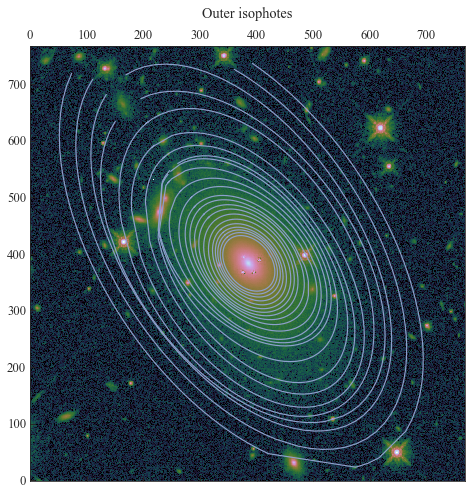

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.matshow(np.log10(np.abs(large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title("Outer isophotes")

#ax.set_xlim(limits)
#ax.set_ylim(limits)

isos = []
for sma in isolist_outer.to_table()['sma']:
    iso = isolist_outer.get_closest(sma)
    isos.append(iso)
    x, y, = iso.sampled_coordinates()
    plt.plot(x, y, color=pf.cb2_blue)

Text(0, 0.5, 'Intensity')

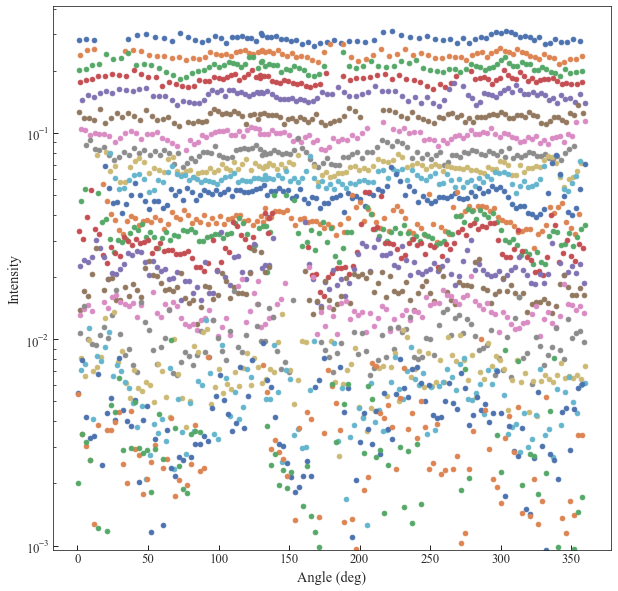

In [17]:
plt.figure(figsize=(10, 10))

for iso in isos:
    angles = ((iso.sample.values[0] + iso.sample.geometry.pa) / np.pi*180.) % 360.
    plt.scatter(angles, iso.sample.values[2])
    

plt.yscale('log')
plt.xlabel("Angle (deg)")
plt.ylabel("Intensity")

Combine the isophotes from inner region and outer region. Drop the last few isophotes in the outer region that are improperly fit.

In [18]:
isolist_full = isolist + isolist_outer[6:-2]

In [19]:
isolist_full.to_table()

sma,intens,intens_err,ellipticity,ellipticity_err,pa,pa_err,grad,grad_err,grad_rerr,x0,x0_err,y0,y0_err,ndata,flag,niter,stop_code
,,,,,deg,deg,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,float64,float64,float64,int64,int64,int64,int64
0.0,28.167439521693524,0.0,0.0,0.0,0.0,0.0,0.0,None,None,385.6100920127983,0.0,383.99076551092804,0.0,1,0,0,0
0.5111130767700377,28.02410033614951,0.005742454695630859,0.8674744290769626,0.005313802145902547,178.6899877926777,0.3308838874590289,-0.26910040526706447,0.1684770106102008,0.6260749048036491,385.6100920127983,0.010261159102465455,383.99076551092804,0.0014651432160076527,13,0,50,2
0.5622243844470415,27.937654762187403,0.011885237893183343,0.8218609828070741,0.008008956664302564,178.6899877926777,0.5061389046690082,-0.5060957263113203,0.28496547718554144,0.563066357549614,385.55507448605243,0.01266017600224809,383.9853585612691,0.0024158901062138844,13,0,26,0
0.6184468228917457,27.66400704375316,0.031561163227715426,0.6462873764774695,0.012268771432829144,175.9224575830541,0.8579967023826912,-1.5770985398137634,0.9806438196339382,0.6218025030634678,385.52647072713194,0.01072128926340918,383.9735791426033,0.004103336673625171,13,0,10,0
0.6802915051809203,27.320513533298616,0.041937480808692744,0.4519374302749299,0.014866979404189443,171.84347446505225,1.300138204324024,-2.4420796292539166,1.0937779722789869,0.44788792272639716,385.5232669406608,0.009182300339171293,383.9478360357695,0.005492117545712604,13,0,11,0
0.7483206556990124,26.910944510763116,0.05364079850533813,0.26103257768799687,0.018007470695573548,162.770617179071,2.4273211780761184,-3.1688262086158767,1.1844717705874885,0.37378880778219087,385.5345938904041,0.008979478698644407,383.92975194250914,0.007370902553003442,13,0,10,0
0.8231527212689137,26.55243590540785,0.049960947566764786,0.17355209296820653,0.015659069259796012,148.48479530985125,3.0228637312088473,-3.452791251944827,1.0278522649264616,0.297687346244147,385.5142319139653,0.007565580848025154,383.9239230956662,0.007137342860294591,13,0,10,0
0.9054679933958051,26.323455863916106,0.052664139258818736,0.1778037122101518,0.014080463094097266,136.26240498679235,2.658970993317178,-3.6599572917737886,0.8963003350203241,0.2448936595612389,385.51225347936344,0.007317333338503665,383.91347042231354,0.007274442016006169,13,0,10,0


In [20]:
model_image = build_ellipse_model(large_image.shape, isolist_full)
#residual = data - model_image

#plt.matshow(np.log10(model_image), origin='lower')

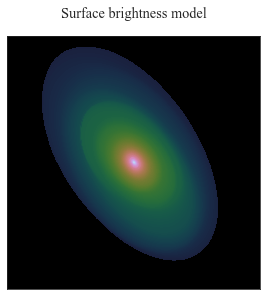

In [21]:
fig, ax = plt.subplots(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))

ax.matshow(np.log10(model_image+1e-3), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)

ax.set_title('Surface brightness model')

ax.set_xticks([])
ax.set_yticks([])

# plt.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/large_coutout_model.pdf', 
#             bbox_inches='tight')
plt.show()


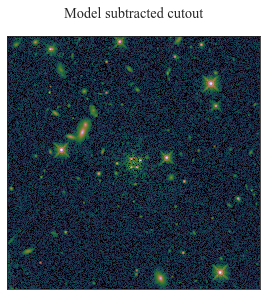

In [22]:
fig, ax = plt.subplots(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))

ax.matshow(np.log10(np.abs(-model_image + large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title('Model subtracted cutout')

ax.set_xticks([])
ax.set_yticks([]);


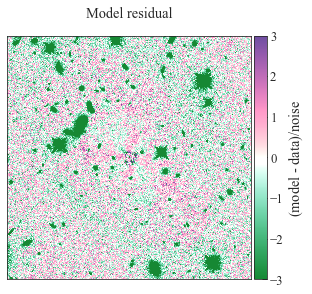

In [23]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig, ax = plt.subplots(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))

noise = np.sqrt(np.abs(kwargs_data_large['image_data'] / kwargs_data_large['exposure_time']) + kwargs_data_large['background_rms']**2)

cbar = ax.matshow((model_image - large_image)/noise, origin='lower', cmap=msh_cmap2, vmax=3, vmin=-3)

ax.set_title('Model residual')

ax.set_xticks([])
ax.set_yticks([])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

plt.colorbar(cbar, cax=cax, label=r'(model - data)$/$noise')

# plt.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/large_coutout_model_residual.pdf', 
#             bbox_inches='tight')
plt.show()


### make figure for paper

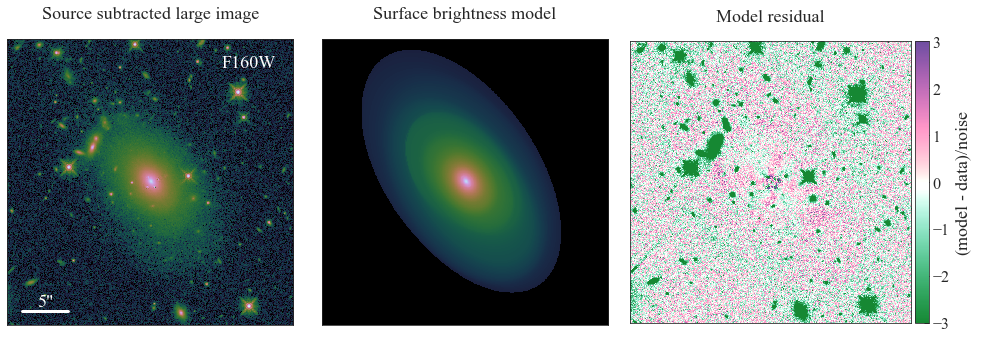

In [24]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig = plt.figure(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth, height_ratio=1/3))

ax = fig.add_subplot(131)
ax.matshow(np.log10(np.abs(large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title('Source subtracted large image', fontdict={'fontsize': pf.mnras_text_fontsize*2})

ax.text(0.75, 0.9, 'F160W', color='white', fontdict={'fontsize': pf.mnras_text_fontsize*2},
        transform=ax.transAxes
       )

add_scale_bar(ax, length=5, fontsize=pf.mnras_text_fontsize*2, scale_text=None);
    
ax.set_xticks([])
ax.set_yticks([])
# plt.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/source_subtracted_large_cutout.pdf', 
#             bbox_inches='tight')

ax = fig.add_subplot(132)

ax.matshow(np.log10(model_image+1e-3), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)

ax.set_title('Surface brightness model', fontdict={'fontsize': pf.mnras_text_fontsize*2})

ax.set_xticks([])
ax.set_yticks([])


ax = fig.add_subplot(133)

noise = np.sqrt(np.abs(kwargs_data_large['image_data'] / kwargs_data_large['exposure_time']) + kwargs_data_large['background_rms']**2)

cbar = ax.matshow((model_image - large_image)/noise, origin='lower', cmap=msh_cmap2, vmax=3, vmin=-3)

ax.set_title('Model residual', fontdict={'fontsize': pf.mnras_text_fontsize*2})

ax.set_xticks([])
ax.set_yticks([])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

colorbar = plt.colorbar(cbar, cax=cax)
colorbar.set_label(label=r'(model - data)$/$noise', fontsize=pf.mnras_text_fontsize*2)
colorbar.ax.tick_params(labelsize=pf.mnras_figcaption_fontsize*2)

fig.tight_layout()

# fig.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/large_cutout_model.pdf', 
#             bbox_inches='tight')

plt.show()


In [25]:
# total apparent magnitude

from astropy.io.fits import getheader

total_flux = np.sum(model_image)

data_total_eletrons = large_image_backup * wht_map
data_total_eletrons[data_total_eletrons < 0. ] = 0.

flux_noise = np.sqrt(data_total_eletrons/wht_map**2 + bkg_rms**2)
flux_noise[model_image <= 0] = 0.

total_flux_noise = np.sqrt(np.sum(flux_noise**2))

print(total_flux, total_flux_noise)

header = getheader('../data/reduced_data/DESJ2038-4008_F160W_drz_sci.fits')

photflam, photzpt, photplam =  header['PHOTFLAM'], header['PHOTZPT'], header['PHOTPLAM']


def get_stmag(electron_flux, photflam, photzpt):
    electron_flux = np.asarray(electron_flux)
    scalar_input = False
    if electron_flux.ndim == 0:
        electron_flux = electron_flux[None]  
        scalar_input = True

    flux = electron_flux * photflam
    mag = -2.5 * np.log10(flux) + photzpt

    if scalar_input:
        return np.squeeze(mag)

    return mag

def get_abmag(electron_flux, photflam, photzpt, photplam):
    stmag = get_stmag(electron_flux, photflam, photzpt)

    return stmag - 5. * np.log10(photplam) + 2.5 * np.log10(299792458e10) - 27.5

mag_distribution = get_abmag(np.random.normal(loc=total_flux, scale=total_flux_noise, size=1000), photflam, photzpt, photplam)

print(np.mean(mag_distribution), np.std(mag_distribution))

14139.110256891849 7.098965
15.5702232937479 0.0005547369671096535


### Find half-light radius

In [26]:
from photutils import CircularAperture
from photutils import aperture_photometry

positions = [(242+96*1.5, 240+96*1.5)]


total_flux = np.sum(model_image)

for r in range(1, 200):
    aperture = CircularAperture(positions, r=r)

    phot_table = aperture_photometry(model_image, aperture)
    if phot_table[0]['aperture_sum'] >= total_flux/2.:
        break
print("Pixels:", r, ", Radius: ", r * 0.08, "arcsecond")

Pixels: 40 , Radius:  3.2 arcsecond


In [27]:
aperture = CircularAperture(positions, r=1.36/0.08)
phot_table = aperture_photometry(model_image, aperture)

phot_table[0]['aperture_sum']/total_flux

0.29075938212587166

## Fit MGE

Here we fit a MGE to the light model to use the MGE light profiles in the kinematic computation.

In [28]:
import mgefit
from mgefit.find_galaxy import find_galaxy
from mgefit.mge_fit_1d import mge_fit_1d
from mgefit.sectors_photometry import sectors_photometry
from mgefit.mge_fit_sectors import mge_fit_sectors
from mgefit.mge_print_contours import mge_print_contours
from mgefit.mge_fit_sectors_twist import mge_fit_sectors_twist
from mgefit.sectors_photometry_twist import sectors_photometry_twist
from mgefit.mge_print_contours_twist import mge_print_contours_twist


### fit Gaussians to the PSF 

In [29]:
mean_psf_profile = (np.sum(kwargs_psf['kernel_point_source'], axis=0) + np.sum(kwargs_psf['kernel_point_source'], axis=1))/2.

psf_size = len(mean_psf_profile)

one_sided_psf_profile = mean_psf_profile[:int((psf_size-1)/2)+1][::-1] + mean_psf_profile[-int((psf_size-1)/2)-1:]

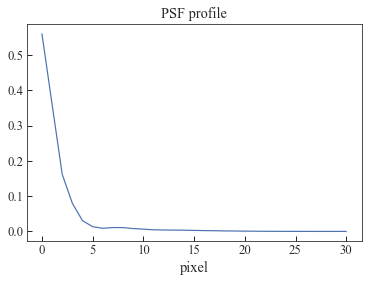

In [30]:
from scipy.interpolate import interp1d

n = 100  # number of sampled points
x = np.geomspace(0.01, 30, n)  # logarithmically spaced radii
y = interp1d(np.arange(len(one_sided_psf_profile)), one_sided_psf_profile)(x)  # The profile must be logarithmically sampled!
    
plt.plot(one_sided_psf_profile)
plt.title('PSF profile')
plt.xlabel('pixel')
plt.show()



Iteration: 1  chi2: 11.39 Nonzero: 6/9
Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
Iteration: 6  chi2: 3.17 Nonzero: 5/5
############################################
 Computation time: 0.04 seconds
 Total Iterations:  6
Nonzero Gaussians:  5
 Unused Gaussians:  4
 Chi2: 3.17 
 STDEV: 0.1752
 MEANABSDEV: 0.07697
############################################
 Total_Counts      Sigma
############################################
  0.000493634    0.0190788
    0.0175821     0.171928
     0.239713     0.692785
      1.42357      1.60139
      0.31035      7.23759
############################################


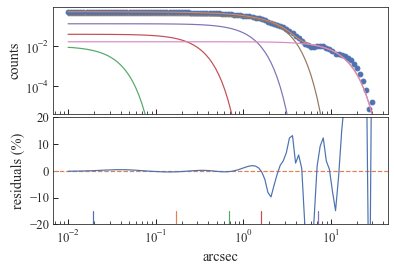

In [31]:
p = mge_fit_1d(x, y, plot=True, ngauss=9)

In [32]:
p.sol

array([[4.93633998e-04, 1.75821342e-02, 2.39712939e-01, 1.42357230e+00,
        3.10349787e-01],
       [1.90788314e-02, 1.71927709e-01, 6.92784518e-01, 1.60139184e+00,
        7.23758683e+00]])

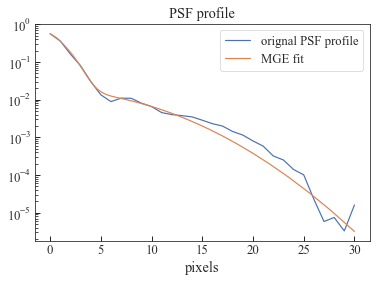

In [33]:
plt.plot(one_sided_psf_profile, label='orignal PSF profile')
plt.plot(p.x, np.sum(p.gauss*p.sol[0, :], axis=1), label='MGE fit')
plt.yscale('log')
plt.title('PSF profile')
plt.xlabel('pixels')
plt.legend()
plt.show()


### fit MGE to the galaxy model

 Pixels used: 176947
 Peak Img[j, k]: 384 385
 Mean (j, k): 383.27 385.66
 Theta (deg): 54.1
 Astro PA (deg): 35.9
 Eps: 0.397
 Major axis (pix): 312.4


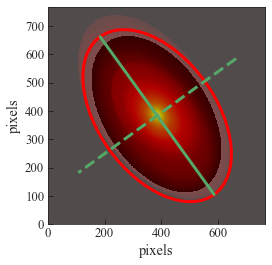

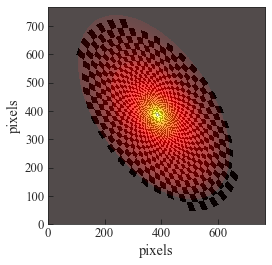

Iteration: 1  chi2: 7.248  Nonzero: 14/20
Iteration: 11  chi2: 1.318  Nonzero: 13/20
Iteration: 21  chi2: 1.034  Nonzero: 10/20
Nonzero Gaussians: 10/20
Eliminating not useful Gaussians...
ngauss: 9           chi2: 1.03
ngauss: 8           chi2: 1.03
Starting nonlinear fit...
Iteration: 1  chi2: 1.031  Nonzero: 8/8
Nonzero Gaussians: 8/8
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
 Computation time: 13.29 seconds
  Total Iterations:  25
 Nonzero Gaussians:  8
  Unused Gaussians:  12
 Sectors used in the fit:  19
 Total number of points fitted:  810
 Chi2: 1.019 
 STDEV: 0.03544 
 MEANABSDEV: 0.02052 
############################################
  Total_Counts  Sigma_Pixels      qObs
############################################
      108.691      1.72223     0.810516
      799.046      3.93909     0.678697
      1536.82      8.44827     0.663877
      2510.47      16.7011     0.757222
      2425.15      36.1159     0.714297


Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a 

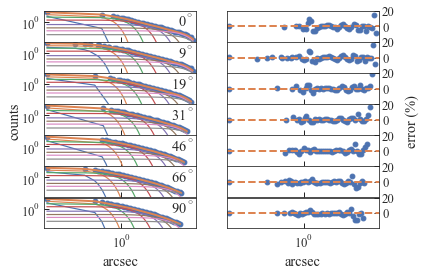

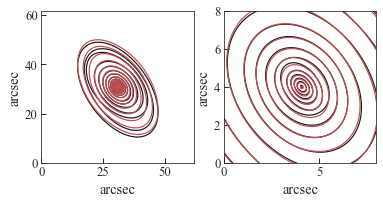

In [32]:
from mge_fit_sectors_regularized import mge_fit_sectors_regularized

img = model_image

scale = 0.08  # arcsec/pixel
minlevel = 0.002  # counts/pixel
ngauss = 20

sigmapsf = p.sol[:, 1]      # In pixels
normpsf = p.sol[:, 0] / np.sum(p.sol[:, 0])  # total(normpsf)=1


# Here we use FIND_GALAXY directly inside the procedure. Usually you may want
# to experiment with different values of the FRACTION keyword, before adopting
# given values of Eps, Ang, Xc, Yc.
plt.clf()
f = find_galaxy(img, fraction=0.3, plot=1)
plt.show()

# Perform galaxy photometry
plt.clf()
s = sectors_photometry(img, f.eps, f.theta, f.xpeak, f.ypeak,
                       minlevel=minlevel, plot=1)
plt.show()

# Do the actual MGE fit
# *********************** IMPORTANT ***********************************
# For the final publication-quality MGE fit one should include the line
# "from mge_fit_sectors_regularized import mge_fit_sectors_regularized"
# at the top of this file, rename mge_fit_sectors() into
# mge_fit_sectors_regularized() and re-run the procedure.
# See the documentation of mge_fit_sectors_regularized for details.
# *********************************************************************
plt.clf()
m = mge_fit_sectors_regularized(s.radius, s.angle, s.counts, f.eps,
                    ngauss=ngauss, sigmapsf=sigmapsf, normpsf=normpsf,
                    scale=scale, plot=1, bulge_disk=0, linear=0)
plt.show()

# Show contour plots of the results
plt.clf()
plt.subplot(121)
mge_print_contours(img.clip(minlevel), f.theta, f.xpeak, f.ypeak, m.sol, scale=scale,
                   binning=7, sigmapsf=sigmapsf, normpsf=normpsf, magrange=9)

# Extract the central part of the image to plot at high resolution.
# The MGE is centered to fractional pixel accuracy to ease visual comparison.

n = 50
img = img[f.xpeak-n:f.xpeak+n, f.ypeak-n:f.ypeak+n]
xc, yc = n - f.xpeak + f.xmed, n - f.ypeak + f.ymed
plt.subplot(122)
mge_print_contours(img, f.theta, xc, yc, m.sol,
                   sigmapsf=sigmapsf, normpsf=normpsf, scale=scale)


In [33]:
sigmas = m.sol[1, :] * np.sqrt(1 - f.eps) * scale
amps = m.sol[0, :]

In [34]:
amps, sigmas

(array([ 108.69100868,  799.04561399, 1536.81696056, 2510.46534315,
        2425.14639225, 2188.20896608, 3075.68274026, 1808.28311979]),
 array([ 0.10700896,  0.24475083,  0.52492347,  1.03770399,  2.24402017,
         3.74713874,  8.58773362, 10.27207989]))

### Plot the MGE profile and compare with the isophote-based model

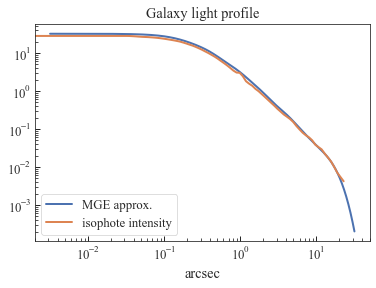

In [35]:
#plt.plot(m.radius * scale, np.sum(m.gauss*m.sol[0, :], axis=1), label='MGE fit', ls='none', marker='o')

xs = np.logspace(-2.5, 1.5, 1000)

mge_profile = 0
for a, s in zip(amps, sigmas):
    mge_profile += a / (2*np.pi) / s**2 * np.exp(-xs**2/2./s**2) * 0.08**2

amp = interp1d(xs, mge_profile)(3.2) * 8.

plt.plot(xs, mge_profile, label='MGE approx.', lw=2)
plt.plot(isolist_full.to_table()['sma'] * 0.08 * np.sqrt(1 - f.eps), 
         isolist_full.to_table()['intens'], label='isophote intensity', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Galaxy light profile')
plt.xlabel('arcsec')
plt.legend()
plt.show()
